In [1]:
import pandas as pd

In [84]:
data=pd.read_csv('ecommerce_sales_analytics_5000.csv')
data.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [86]:
data.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [90]:
#First we format the date data
date_data=pd.to_datetime(data['order_date'],format='%m/%d/%Y')

In [91]:
data['month']=date_data.dt.month

In [92]:
data['year']=date_data.dt.year

In [93]:
data['day']=date_data.dt.day

In [94]:
data.drop('order_date',axis=1,inplace=True)

In [95]:
data.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,year,day
0,10001,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,1,2022,1
1,10002,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,1,2022,2
2,10003,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,1,2022,3
3,10004,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,1,2022,4
4,10005,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,1,2022,5


In [96]:
#Now we change every object type into lower case 

In [97]:
data['product_category']=data['product_category'].str.lower()

In [98]:
data['region']=data['region'].str.lower()

In [99]:
data['payment_method']=data['payment_method'].str.lower()


In [101]:
#
data.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,year,day
0,10001,1102,beauty,south,7,373.65,0.28,wallet,10,4.7,1883.20,1,2022,1
1,10002,1435,clothing,south,7,47.74,0.09,card,6,3.9,304.10,1,2022,2
2,10003,1860,beauty,east,3,311.28,0.31,cod,6,2.5,644.35,1,2022,3
3,10004,1270,electronics,west,5,524.47,0.02,wallet,6,1.6,2569.90,1,2022,4
4,10005,1106,clothing,west,5,139.87,0.33,wallet,4,4.9,468.56,1,2022,5


In [105]:
data['product_category'].value_counts()

product_category
electronics    1777
clothing       1531
home            969
beauty          723
Name: count, dtype: int64

In [118]:
#Now we will find which product is generting more revenue
data.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

product_category
electronics    1829899.22
clothing       1531931.72
home            982083.92
beauty          765860.88
Name: revenue, dtype: float64

In [111]:
##above numbers shows that most of the revenue is generated by beatuy products 

In [119]:
#Now we will calculate the revenue generated from each product and for that product which regions impacts more using the pivot function
pivot_table=pd.pivot_table(
    data,
    values='revenue',
    index='product_category',
    columns='region',
    aggfunc='sum')
    

In [120]:
pivot_table

region,east,north,south,west
product_category,,,,
beauty,174909.11,186213.32,191073.98,213664.47
clothing,402582.60,364659.43,348363.14,416326.55
electronics,411803.35,472450.93,487055.68,458589.26
home,246749.17,258184.77,220148.10,257001.88


In [124]:
data.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,year,day
0,10001,1102,beauty,south,7,373.65,0.28,wallet,10,4.7,1883.20,1,2022,1
1,10002,1435,clothing,south,7,47.74,0.09,card,6,3.9,304.10,1,2022,2
2,10003,1860,beauty,east,3,311.28,0.31,cod,6,2.5,644.35,1,2022,3
3,10004,1270,electronics,west,5,524.47,0.02,wallet,6,1.6,2569.90,1,2022,4
4,10005,1106,clothing,west,5,139.87,0.33,wallet,4,4.9,468.56,1,2022,5


In [123]:
data['payment_method'].value_counts()

payment_method
card      2270
cod       1774
wallet     956
Name: count, dtype: int64

In [130]:
data.groupby('product_category')['payment_method'].value_counts()

product_category  payment_method
beauty            card              339
                  cod               258
                  wallet            126
clothing          card              708
                  cod               533
                  wallet            290
electronics       card              816
                  cod               622
                  wallet            339
home              card              407
                  cod               361
                  wallet            201
Name: count, dtype: int64

In [133]:
#Now we will find which product gives most discount
data.groupby('product_category')['discount'].max()

product_category
beauty         0.35
clothing       0.35
electronics    0.35
home           0.35
Name: discount, dtype: float64

In [138]:
discounts_per_each_region=pd.pivot_table(
    data,
    values='discount',
    index='product_category',
    columns='region',
    aggfunc='max')

In [139]:
discounts_per_each_region

region,east,north,south,west
product_category,,,,
beauty,0.35,0.35,0.35,0.34
clothing,0.35,0.35,0.35,0.35
electronics,0.35,0.35,0.35,0.35
home,0.35,0.35,0.35,0.35


In [140]:
data.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,year,day
0,10001,1102,beauty,south,7,373.65,0.28,wallet,10,4.7,1883.20,1,2022,1
1,10002,1435,clothing,south,7,47.74,0.09,card,6,3.9,304.10,1,2022,2
2,10003,1860,beauty,east,3,311.28,0.31,cod,6,2.5,644.35,1,2022,3
3,10004,1270,electronics,west,5,524.47,0.02,wallet,6,1.6,2569.90,1,2022,4
4,10005,1106,clothing,west,5,139.87,0.33,wallet,4,4.9,468.56,1,2022,5


In [151]:
#now we will check in which year we got max discount for each product
discounts_per_each_year=pd.pivot_table(
    data,
    values='discount',
    index='year',
    columns=['region','product_category'],
    aggfunc='max')

In [152]:
discounts_per_each_year

region             east                             north           \
product_category beauty clothing electronics  home beauty clothing   
year                                                                 
2022               0.33     0.33        0.35  0.33   0.31     0.34   
2023               0.32     0.35        0.34  0.35   0.32     0.35   
2024               0.35     0.35        0.35  0.34   0.33     0.34   
2025               0.32     0.34        0.35  0.35   0.34     0.34   
2026               0.35     0.32        0.35  0.34   0.29     0.35   
2027               0.31     0.35        0.34  0.33   0.34     0.35   
2028               0.27     0.33        0.35  0.33   0.34     0.34   
2029               0.34     0.34        0.34  0.34   0.33     0.34   
2030               0.29     0.33        0.35  0.35   0.34     0.33   
2031               0.34     0.32        0.35  0.31   0.33     0.34   
2032               0.32     0.34        0.34  0.31   0.34     0.34   
2033               0.30     0.35        0.34  0.35   0.33     0.34   
2034               0.34     0.34        0.34  0.29   0.35     0.35   
2035               0.27     0.32        0.33  0.35   0.22     0.34   

region                              south                              west  \
product_category electronics  home beauty clothing electronics  home beauty   
year                                                                          
2022                    0.33  0.34   0.30     0.33        0.35  0.33   0.27   
2023                    0.34  0.31   0.29     0.33        0.32  0.34   0.34   
2024                    0.34  0.35   0.34     0.35        0.33  0.30   0.33   
2025                    0.35  0.35   0.35     0.35        0.35  0.35   0.34   
2026                    0.35  0.34   0.30     0.32        0.34  0.34   0.30   
2027                    0.35  0.34   0.33     0.35        0.33  0.31   0.29   
2028                    0.34  0.30   0.32     0.35        0.35  0.33   0.32   
2029                    0.35  0.29   0.34     0.34        0.34  0.34   0.34   
2030                    0.34  0.35   0.32     0.33        0.35  0.34   0.34   
2031                    0.32  0.34   0.22     0.34        0.35  0.32   0.34   
2032                    0.34  0.31   0.34     0.33        0.34  0.35   0.34   
2033                    0.34  0.34   0.34     0.32        0.35  0.34   0.32   
2034                    0.35  0.34   0.34     0.35        0.35  0.34   0.33   
2035                    0.34  0.31   0.31     0.35        0.32  0.35   0.33   

region                                       
product_category clothing electronics  home  
year                                         
2022                 0.33        0.35  0.35  
2023                 0.35        0.33  0.33  
2024                 0.34        0.34  0.35  
2025                 0.35        0.34  0.32  
2026                 0.35        0.35  0.31  
2027                 0.34        0.33  0.34  
2028                 0.35        0.34  0.32  
2029                 0.34        0.35  0.35  
2030                 0.35        0.35  0.35  
2031                 0.35        0.33  0.34  
2032                 0.35        0.35  0.35  
2033                 0.34        0.34  0.31  
2034                 0.34        0.35  0.34  
2035                 0.34        0.35  0.24

In [154]:
#We willc calculate how prices are chaning over the coruse of years for each product
change_in_price_over_years=pd.pivot_table(
    data,
    values='unit_price',
    columns='product_category',
    index='year',
    aggfunc='mean')
    
change_in_price_over_years

product_category,beauty,clothing,electronics,home
year,,,,
2022,301.885094,292.777664,293.093615,325.481333
2023,298.591020,284.130556,300.771395,321.889114
2024,301.039592,298.849245,328.757132,301.053415
2025,295.400217,296.671714,305.742406,314.670617
2026,315.287826,319.792560,316.991746,315.010441
2027,297.153818,282.952222,305.814127,310.784342
2028,271.721296,327.163519,311.671915,324.035238
2029,317.101613,303.775089,294.680385,291.010984
2030,293.597091,313.713000,333.521418,291.977368


In [157]:
#now we will calculate how revenue is changing for each year ,for each product type
revenue_per_each_year=pd.pivot_table(
    data,
    values='revenue',
    columns='product_category',
    index='year',
    aggfunc='sum')
    
revenue_per_each_year

product_category,beauty,clothing,electronics,home
year,,,,
2022,54504.02,106877.62,131811.12,78631.54
2023,56706.96,98516.53,124798.88,85893.42
2024,53364.95,102318.80,132421.76,75103.62
2025,40779.11,101267.17,133241.71,74514.34
2026,48280.40,130968.56,129437.49,77683.24
2027,62982.92,116035.92,131788.52,75344.55
2028,50435.70,108907.29,146293.07,71208.74
2029,64849.62,112028.21,122490.05,59871.36
2030,55721.33,103972.29,151539.83,76651.01


In [158]:
data.head

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,year,day
0,10001,1102,beauty,south,7,373.65,0.28,wallet,10,4.7,1883.20,1,2022,1
1,10002,1435,clothing,south,7,47.74,0.09,card,6,3.9,304.10,1,2022,2
2,10003,1860,beauty,east,3,311.28,0.31,cod,6,2.5,644.35,1,2022,3
3,10004,1270,electronics,west,5,524.47,0.02,wallet,6,1.6,2569.90,1,2022,4
4,10005,1106,clothing,west,5,139.87,0.33,wallet,4,4.9,468.56,1,2022,5


In [160]:
#Now we will caluclate the each producy type avg rating for each region

rating_per_each_product_type=pd.pivot_table(
    data,
    index='region',
    values='customer_rating',
    columns='product_category',
    aggfunc='mean')
rating_per_each_product_type

product_category,beauty,clothing,electronics,home
region,,,,
east,2.952727,3.066582,2.906938,2.949799
north,3.172680,2.947354,2.938528,3.025207
south,2.965698,2.966575,2.987253,2.930556
west,2.930729,3.034606,2.968778,2.862214


In [163]:
data.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,year,day
0,10001,1102,beauty,south,7,373.65,0.28,wallet,10,4.7,1883.20,1,2022,1
1,10002,1435,clothing,south,7,47.74,0.09,card,6,3.9,304.10,1,2022,2
2,10003,1860,beauty,east,3,311.28,0.31,cod,6,2.5,644.35,1,2022,3
3,10004,1270,electronics,west,5,524.47,0.02,wallet,6,1.6,2569.90,1,2022,4
4,10005,1106,clothing,west,5,139.87,0.33,wallet,4,4.9,468.56,1,2022,5


In [172]:
#we will check how a product ratings has been increased over the years
changes_in_ratings_over_year=pd.pivot_table(
    data,
    index='year',
    values='customer_rating',
    columns='product_category',
    aggfunc='mean')
changes_in_ratings_over_year

product_category,beauty,clothing,electronics,home
year,,,,
2022,3.100000,2.939252,2.832308,2.974667
2023,2.936735,3.087963,2.974419,2.854430
2024,2.887755,3.058491,2.999225,2.996341
2025,3.000000,2.933333,3.081955,2.820988
2026,2.734783,3.043200,3.052381,2.889706
2027,3.240000,2.976852,2.971429,2.948684
2028,2.985185,2.862037,2.869504,2.980952
2029,2.974194,2.924107,2.958462,2.850820
2030,3.036364,3.182000,2.980597,3.093421


In [176]:
#we will now check what is the avg delivery days for each region
data.groupby('region')['delivery_days'].mean()

region
east     6.104319
north    6.118339
south    6.173013
west     6.082234
Name: delivery_days, dtype: float64

In [180]:
#now we will check from region we have most customers
data.groupby('region')['customer_id'].count()

region
east     1227
north    1276
south    1208
west     1289
Name: customer_id, dtype: int64

In [181]:
#now we will check from product type we have most customers
data.groupby('product_category')['customer_id'].count()

product_category
beauty          723
clothing       1531
electronics    1777
home            969
Name: customer_id, dtype: int64

In [182]:
data.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,year,day
0,10001,1102,beauty,south,7,373.65,0.28,wallet,10,4.7,1883.20,1,2022,1
1,10002,1435,clothing,south,7,47.74,0.09,card,6,3.9,304.10,1,2022,2
2,10003,1860,beauty,east,3,311.28,0.31,cod,6,2.5,644.35,1,2022,3
3,10004,1270,electronics,west,5,524.47,0.02,wallet,6,1.6,2569.90,1,2022,4
4,10005,1106,clothing,west,5,139.87,0.33,wallet,4,4.9,468.56,1,2022,5


In [188]:
#now we will start the visualizing the data we have 
import matplotlib.pyplot as plt
data.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,year,day
0,10001,1102,beauty,south,7,373.65,0.28,wallet,10,4.7,1883.20,1,2022,1
1,10002,1435,clothing,south,7,47.74,0.09,card,6,3.9,304.10,1,2022,2
2,10003,1860,beauty,east,3,311.28,0.31,cod,6,2.5,644.35,1,2022,3
3,10004,1270,electronics,west,5,524.47,0.02,wallet,6,1.6,2569.90,1,2022,4
4,10005,1106,clothing,west,5,139.87,0.33,wallet,4,4.9,468.56,1,2022,5


In [193]:
how_much_each_product=data.groupby('product_category')['quantity'].sum()

In [197]:
how_much_each_product

product_category
beauty         2995
clothing       6171
electronics    7109
home           3949
Name: quantity, dtype: int64

Text(0, 0.5, 'quantity they are sold')

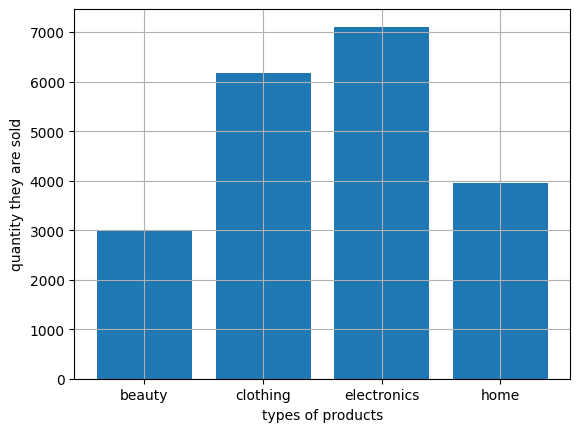

In [293]:
plt.bar(how_much_each_product.index,how_much_each_product.values)
plt.xlabel('types of products')
plt.grid()
plt.ylabel('quantity they are sold')

In [204]:
data.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,year,day
0,10001,1102,beauty,south,7,373.65,0.28,wallet,10,4.7,1883.20,1,2022,1
1,10002,1435,clothing,south,7,47.74,0.09,card,6,3.9,304.10,1,2022,2
2,10003,1860,beauty,east,3,311.28,0.31,cod,6,2.5,644.35,1,2022,3
3,10004,1270,electronics,west,5,524.47,0.02,wallet,6,1.6,2569.90,1,2022,4
4,10005,1106,clothing,west,5,139.87,0.33,wallet,4,4.9,468.56,1,2022,5


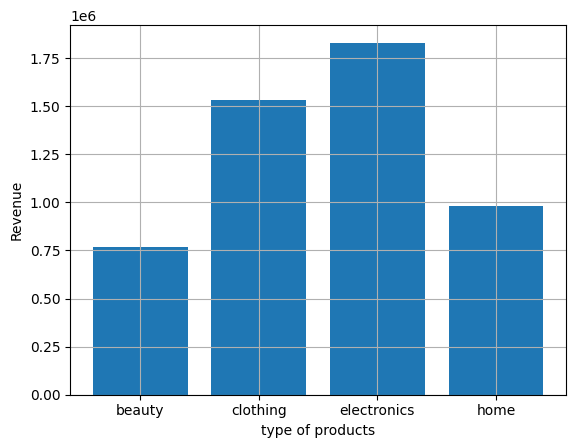

In [294]:
#now we will check how much each product generates the revenue 
how_much_revenue=data.groupby('product_category')['revenue'].sum()
plt.bar(how_much_revenue.index,how_much_revenue.values)
plt.xlabel('type of products')
plt.grid()
plt.ylabel('Revenue')
plt.show()

Text(0, 0.5, 'revenue')

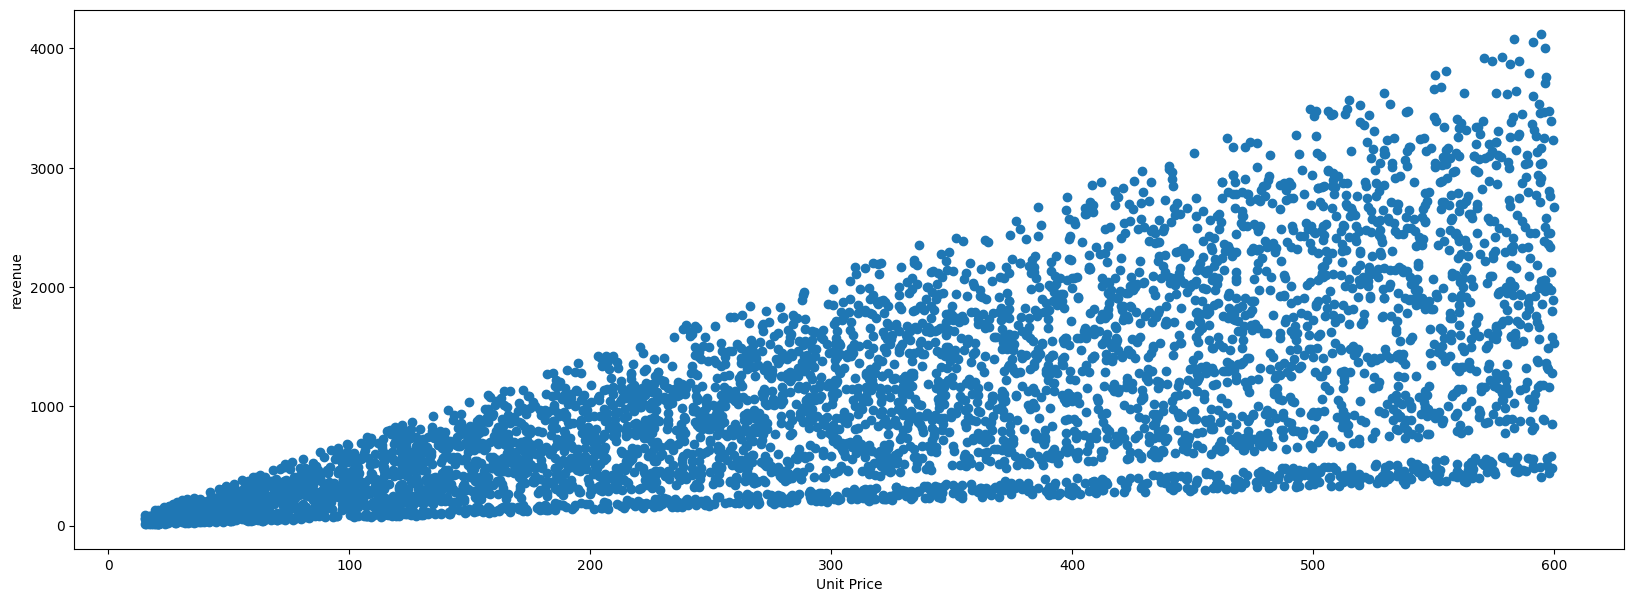

In [218]:
x=data['unit_price']
y=data['revenue']
plt.figure(figsize=(20,7))
plt.scatter(x,y)
plt.xlabel('Unit Price')
plt.ylabel('revenue')

In [286]:
#Now we will check each product price over the years
price_changes=data.groupby('product_category')['unit_price']

In [287]:
electronices_price_over_years=data[data['product_category']=='electronics'][['unit_price','year']]

In [288]:
x=electronices_price_over_years.groupby('year')['unit_price'].mean()

Text(0, 0.5, 'electronics unit_price')

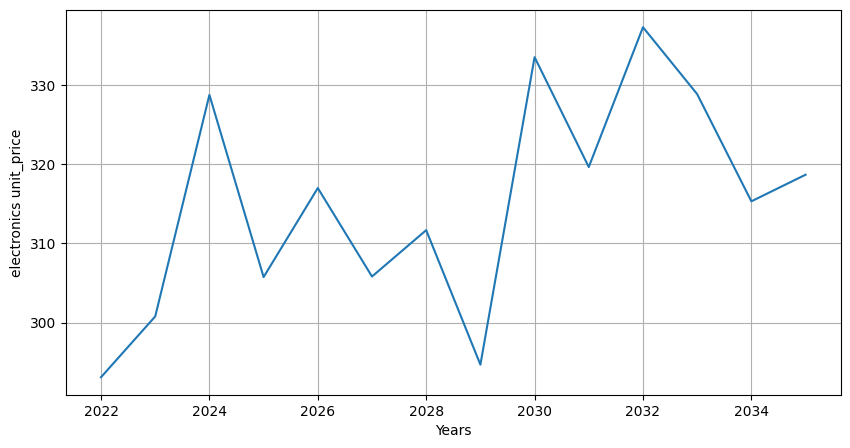

In [289]:
plt.figure(figsize=(10,5))
plt.plot(x.index,x.values)
plt.grid()
plt.xlabel('Years')
plt.ylabel('electronics unit_price')

In [290]:
electronices_revenue_over_years=data[data['product_category']=='electronics'][['revenue','year']]

In [291]:
x=electronices_revenue_over_years.groupby('year')['revenue'].mean()

Text(0, 0.5, 'electronics Revenue')

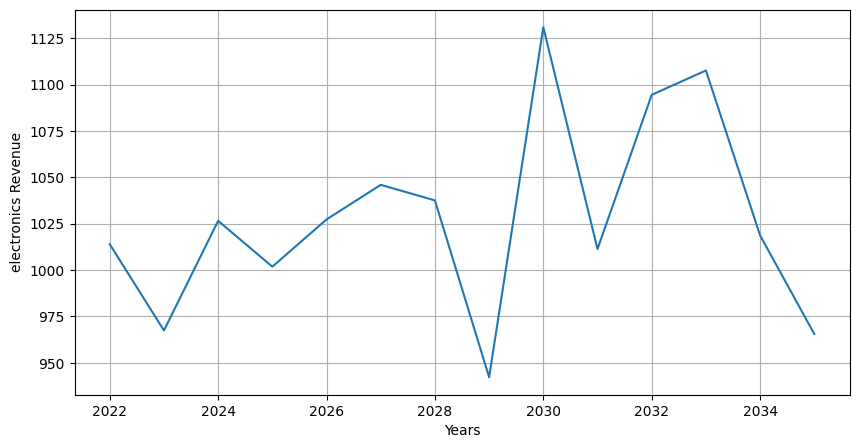

In [292]:
plt.figure(figsize=(10,5))
plt.grid()
plt.plot(x.index,x.values)
plt.xlabel('Years')
plt.ylabel('electronics Revenue')

In [269]:
x_=data['payment_method'].value_counts()

In [270]:
x_

payment_method
card      2270
cod       1774
wallet     956
Name: count, dtype: int64

In [271]:
quantity=x_.values
categories=x_.index

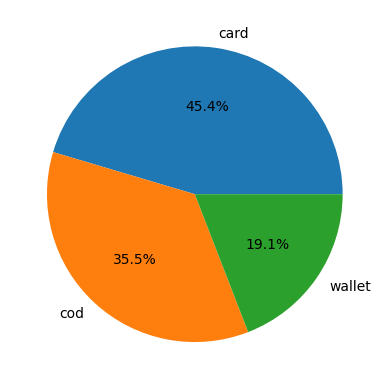

In [274]:
plt.pie(quantity,labels=categories,autopct='%1.1f%%')
plt.show()

In [275]:
data.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,year,day
0,10001,1102,beauty,south,7,373.65,0.28,wallet,10,4.7,1883.20,1,2022,1
1,10002,1435,clothing,south,7,47.74,0.09,card,6,3.9,304.10,1,2022,2
2,10003,1860,beauty,east,3,311.28,0.31,cod,6,2.5,644.35,1,2022,3
3,10004,1270,electronics,west,5,524.47,0.02,wallet,6,1.6,2569.90,1,2022,4
4,10005,1106,clothing,west,5,139.87,0.33,wallet,4,4.9,468.56,1,2022,5


In [277]:
#We will visualize how ratings of electronics changed over
electronices_ratings_over_years=data[data['product_category']=='electronics'][['customer_rating','year']]

In [280]:
x__=electronices_ratings_over_years.groupby('year')['customer_rating'].mean()

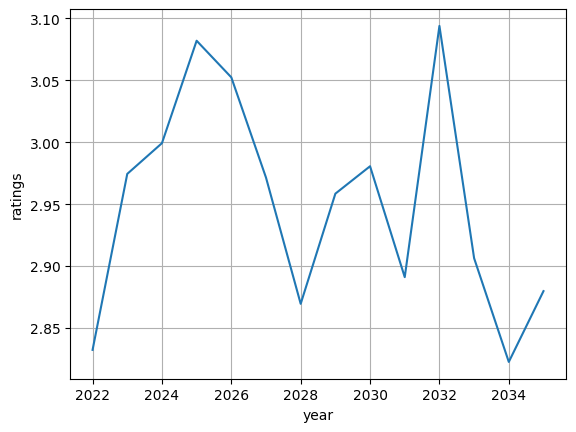

In [283]:
plt.plot(x__.index,x__.values)
plt.xlabel('year')
plt.ylabel('ratings')
plt.grid()
plt.show()

In [296]:
#We will visualize how ratings of electronics changed over
ele_revenue_over_each_region=data[data['product_category']=='electronics'][['region','revenue']]

In [301]:
y=ele_revenue_over_each_region.groupby('region')['revenue'].mean()

<BarContainer object of 4 artists>

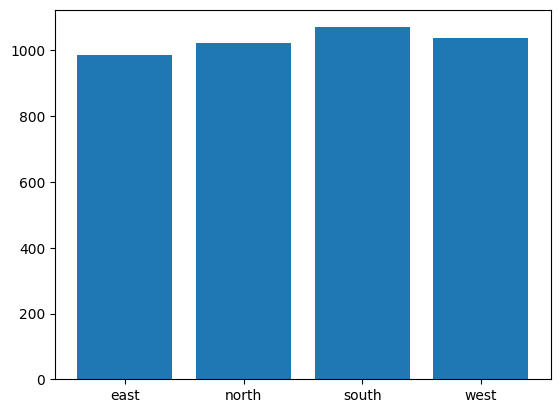

In [305]:
plt.bar(y.index,y.values)
